## **IMPORTS**

In [33]:
# Apache Spark API
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import when, col, count, isnan, sum, mean, median, round, desc

# Data Handling
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

In [34]:
# Iniciando Spark Session
spark = SparkSession.builder \
    .appName("BigData_AC2") \
    .master("local[*]") \
    .config("spark.executor.memory", "12g") \
    .config("spark.driver.memory",   "12g") \
    .getOrCreate()

In [35]:
# Definição de Schema dos dados
raw = spark.read.schema(
    StructType([
      StructField(name="Year", dataType=LongType(), nullable=True),
      StructField(name="Month", dataType=LongType(), nullable=True),
      StructField(name="DayofMonth", dataType=LongType(), nullable=True),
      StructField(name="DayOfWeek", dataType=LongType(), nullable=True),
      StructField(name="DepTime", dataType=DoubleType(), nullable=True),
      StructField(name="CRSDepTime", dataType=LongType(), nullable=True),
      StructField(name="ArrTime", dataType=DoubleType(), nullable=True),
      StructField(name="CRSArrTime", dataType=LongType(), nullable=True),
      StructField(name="UniqueCarrier", dataType=StringType(), nullable=True),
      StructField(name="FlightNum", dataType=LongType(), nullable=True),
      StructField(name="TailNum", dataType=StringType(), nullable=True),
      StructField(name="ActualElapsedTime", dataType=DoubleType(), nullable=True),
      StructField(name="CRSElapsedTime", dataType=DoubleType(), nullable=True),
      StructField(name="AirTime", dataType=DoubleType(), nullable=True),
      StructField(name="ArrDelay", dataType=DoubleType(), nullable=True),
      StructField(name="DepDelay", dataType=DoubleType(), nullable=True),
      StructField(name="Origin", dataType=StringType(), nullable=True),
      StructField(name="Dest", dataType=StringType(), nullable=True),
      StructField(name="Distance", dataType=DoubleType(), nullable=True),
      StructField(name="TaxiIn", dataType=DoubleType(), nullable=True),
      StructField(name="TaxiOut", dataType=DoubleType(), nullable=True),
      StructField(name="Cancelled", dataType=LongType(), nullable=True),
      StructField(name="CancellationCode", dataType=StringType(), nullable=True),
      StructField(name="CarrierDelay", dataType=DoubleType(), nullable=True),
      StructField(name="WeatherDelay", dataType=DoubleType(), nullable=True),
      StructField(name="NASDelay", dataType=DoubleType(), nullable=True),
      StructField(name="SecurityDelay", dataType=DoubleType(), nullable=True),
      StructField(name="LateAircraftDelay", dataType=DoubleType(), nullable=True)
    ])
).parquet("../../../data/airline.parquet", header=True)
print(f"N° samples: {raw.count()}")

# Add ID column
# raw = raw.withColumn("id", monotonically_increasing_id()) 

N° samples: 123534969


## **DATA CLEANING**

### MISSING DATA ANALYSIS BEFORE

In [4]:
# Criando tabela para análise de valores faltantes
missing = raw.select([
    sum(
        when( col(c).isNull() | isnan(col(c)), 1).otherwise(0)
    ).alias(c)
    for c in raw.columns
])

In [5]:
# Aplicando transposição na tebela para orientar as colunas para linhas, e melhorar a visualização
missing = missing.selectExpr(
        "stack({0}, {1}) as (column, missing)".format(
            len(raw.columns),
            ", ".join("'{}', {}".format(c, c) for c in raw.columns)
        )
    ).withColumn(
        "porcentage",
        round(col("missing") / raw.count() * 100, 2)
    ).orderBy(desc("missing"))

In [6]:
missing.show(truncate=False)

+-----------------+---------+----------+
|column           |missing  |porcentage|
+-----------------+---------+----------+
|CancellationCode |122800263|99.41     |
|CarrierDelay     |89329433 |72.31     |
|WeatherDelay     |89329433 |72.31     |
|NASDelay         |89329433 |72.31     |
|SecurityDelay    |89329433 |72.31     |
|LateAircraftDelay|89329433 |72.31     |
|AirTime          |39266398 |31.79     |
|TaxiIn           |37397295 |30.27     |
|TailNum          |37385420 |30.26     |
|TaxiOut          |37382704 |30.26     |
|ActualElapsedTime|2587529  |2.09      |
|ArrDelay         |2587529  |2.09      |
|ArrTime          |2584478  |2.09      |
|DepTime          |2302136  |1.86      |
|DepDelay         |2302136  |1.86      |
|Distance         |202000   |0.16      |
|CRSElapsedTime   |26234    |0.02      |
|Year             |0        |0.0       |
|Month            |0        |0.0       |
|DayofMonth       |0        |0.0       |
+-----------------+---------+----------+
only showing top

In [36]:
# Removendo colunas com muitos dados faltantes
raw = raw.drop(*['LateAircraftDelay', 'SecurityDelay', 'NASDelay', 'WeatherDelay', 'CarrierDelay', 'CancellationCode'])

In [37]:
# Removendo linhas com dados faltantes da coluna 'TailNum'
# Essa coluna representa o código da asa do avião, ou seja, não é possível preencher usando alguma técnica estatísca
raw = raw.na.drop(how='any', subset=('TailNum'))

### BALANCING ANALYSIS

In [9]:
# Dados desbalanceados na coluna alvo original, sendo muito difícil tratar esse desbalanceamento
(raw.groupBy('Cancelled').agg(
    count("Cancelled").alias("count"),
    (count("Cancelled") / raw.count()).alias("percentage")
).show())

+---------+--------+-------------------+
|Cancelled|   count|         percentage|
+---------+--------+-------------------+
|        0|84405331| 0.9797536026567011|
|        1| 1744218|0.02024639734329892|
+---------+--------+-------------------+



In [10]:
# N° de linhas com NULL values da coluna ArrDelay
display(raw.select('ArrDelay').where(col('ArrDelay').isNull()).count())

# N° de linhas com NaN values da coluna ArrDelay
display(raw.select('ArrDelay').where(isnan('ArrDelay')).count())

1932969

0

In [38]:
# Remoção de valores NULL da coluna ArrDelay
# Justamente para criar manter apenas linhas com informação e criar a nova coluna
raw = raw.filter(col("ArrDelay").isNotNull())

In [39]:
# Criando nova coluna alvo para análise de desbalanceamento
# Coluna que representa se o voo atrasou ou não em sua chegada
raw = raw.withColumn(
    "IsDelay",
    when(col("ArrDelay") > 0, True).otherwise(False).cast(IntegerType())
)

In [13]:
# Visualizando os impactos no balanceamento da coluna alvo
(raw.groupBy('IsDelay').agg(
    count("IsDelay").alias("count"),
    (count("IsDelay") / raw.count()).alias("percentage")
).show())

+-------+--------+------------------+
|IsDelay|   count|        percentage|
+-------+--------+------------------+
|      1|38706393|0.4596053769934614|
|      0|45510187|0.5403946230065386|
+-------+--------+------------------+



### OUTLIER ANALYSIS

#### 'ArrDelay' COLUMN TURKEY ANALYSIS

Tukey's method:

IQR = $Q3 - Q1$

lower threshold = $Q1 − 1.5 × IQR$

upper threshold = $Q3 + 1.5 × IQR$

In [40]:
# Cálculo de quartis usando Spark
quantiles = raw.approxQuantile('ArrDelay', [0.25, 0.75], 0.0001)

# Calcula threshold aplicando o método de Turkey
#             Q1 - 1.1 * (Q3 - Q1)
lower_bound = quantiles[0] - 1.1 * (quantiles[1] - quantiles[0])
#             Q3 + 1.1 * (Q3 - Q1)
upper_bound = quantiles[1] + 1.1 * (quantiles[1] - quantiles[0])

# Neste caso, não queremos uma coluna perfeita, sem outliers, ou perder informação importante
# Assim, usamos uma constante de 1.2 no cálculo

In [41]:
# Número de outliers na coluna 'ArrDelay'
raw.select('ArrDelay').filter((col('ArrDelay') < lower_bound) | (col('ArrDelay') > upper_bound)).count()

10208318

In [42]:
# Remoção de valores anômalos da análise Turkey da coluna ArrDelay
raw = raw.filter((col('ArrDelay') >= lower_bound) & (col('ArrDelay') <= upper_bound))

In [17]:
# Após remoção dos outliers, o desbalanceamento aumentou na coluna alvo
(raw.groupBy('IsDelay').agg(
    count("IsDelay").alias("count"),
    (count("IsDelay") / raw.count()).alias("percentage")
).show())

+-------+--------+-------------------+
|IsDelay|   count|         percentage|
+-------+--------+-------------------+
|      1|29295505|0.39584100758912566|
|      0|44712757| 0.6041589924108743|
+-------+--------+-------------------+



### MISSING DATA ANALYSIS AFTER

In [43]:
# Criando tabela para análise de valores faltantes
missing = raw.select([
    sum(
        when( col(c).isNull() | isnan(col(c)), 1).otherwise(0)
    ).alias(c)
    for c in raw.columns
])

In [44]:
# Aplicando transposição na tebela para orientar as colunas para linhas, e melhorar a visualização
missing = missing.selectExpr(
    "stack({0}, {1}) as (column, missing)".format(
        len(raw.columns),
        ", ".join("'{}', {}".format(c, c) for c in raw.columns)
    )
).withColumn(
    "porcentage",
    round(col("missing") / raw.count() * 100, 4)
).orderBy(desc("missing"))

In [45]:
missing.show(truncate=False)

+-----------------+-------+----------+
|column           |missing|porcentage|
+-----------------+-------+----------+
|Distance         |5465   |0.0074    |
|AirTime          |99     |1.0E-4    |
|Year             |0      |0.0       |
|Month            |0      |0.0       |
|DayofMonth       |0      |0.0       |
|DayOfWeek        |0      |0.0       |
|DepTime          |0      |0.0       |
|CRSDepTime       |0      |0.0       |
|ArrTime          |0      |0.0       |
|CRSArrTime       |0      |0.0       |
|UniqueCarrier    |0      |0.0       |
|FlightNum        |0      |0.0       |
|TailNum          |0      |0.0       |
|ActualElapsedTime|0      |0.0       |
|CRSElapsedTime   |0      |0.0       |
|ArrDelay         |0      |0.0       |
|DepDelay         |0      |0.0       |
|Origin           |0      |0.0       |
|Dest             |0      |0.0       |
|TaxiIn           |0      |0.0       |
+-----------------+-------+----------+
only showing top 20 rows



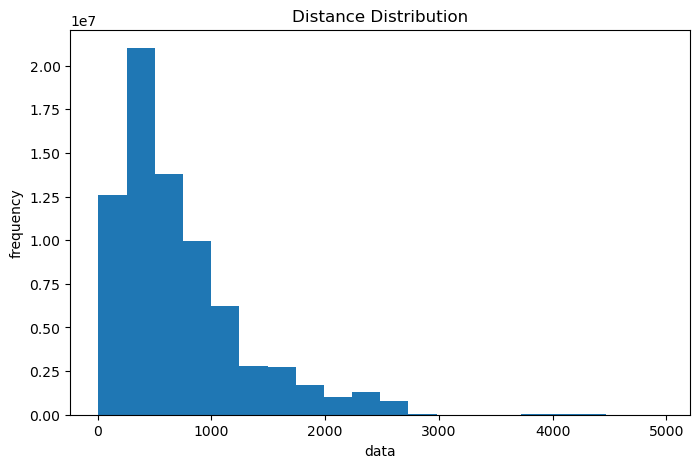

In [21]:
# Visualizando distribuição da coluna Distance
# Distribuição conhecida como Power Law, que por característica, não possui média em seu significado
edges, counts = (
    raw.select("Distance").rdd.flatMap(
        lambda row: row
    ).histogram(18) # qunatidade de barras no plot | aumentando o número de barras para analisar com mais precisão a distribuição
)

plt.figure(figsize=(8,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), align="edge")
plt.xlabel('data')
plt.ylabel('frequency')
plt.title('Distance Distribution')
plt.show()

In [46]:
# Preenchendo com mediana as linhas onde o valor da coluna Distance é nulo
# Mediana é uma medida de localidade, menos sensível a outliers
raw = raw.na.fill({'Distance': raw.approxQuantile("Distance", [0.5], 0.01)[0]})

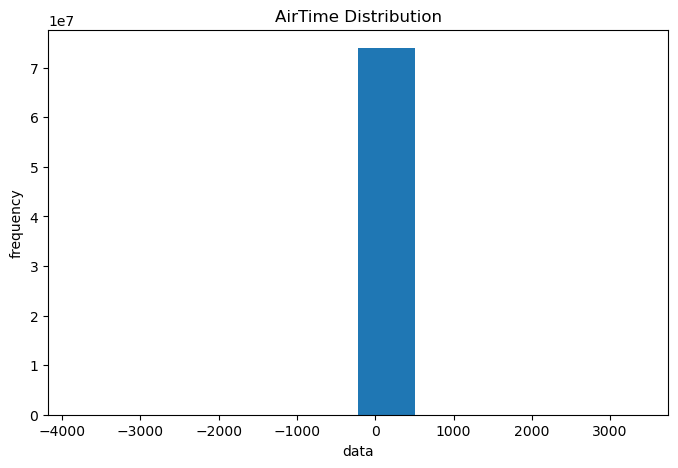

In [28]:
# Visualizando distribuição da coluna AirTime
edges, counts = (
    raw.select("AirTime").rdd.flatMap(
        lambda row: row
    ).histogram(8) # qunatidade de barras no plot
)

plt.figure(figsize=(8,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), align="edge")
plt.xlabel('data')
plt.ylabel('frequency')
plt.title('AirTime Distribution')
plt.show()

In [47]:
# Preenchido valores faltantes com a mediana da coluna
# Mediana é uma medida de localidade, menos sensível a outliers
raw = raw.na.fill({'AirTime': raw.approxQuantile("AirTime", [0.5], 0.01)[0]})

### DISTRIBUTION ANALYSIS

In [48]:
# N° total de linhas no dataset limpo
raw.count()

74008262

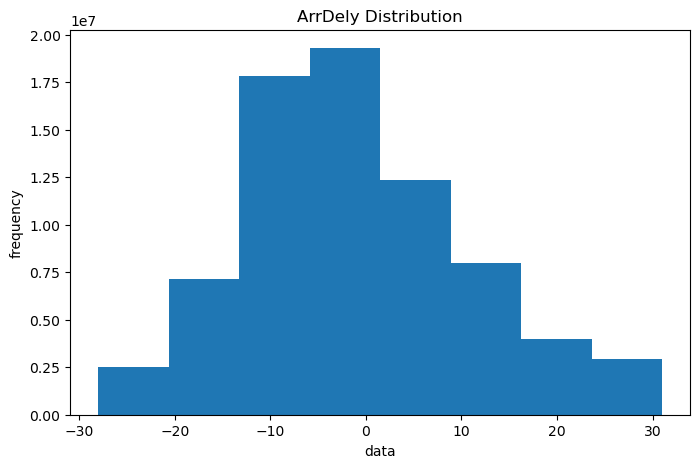

In [32]:
# Após a limpeza realizada anteriormente, percebe-se que os dados da coluna alvo tendem para uma distribuição normal
# Um bom sinal, representando uma coluna com potêncial e qualidade na informação
edges, counts = (
    raw.select("ArrDelay").rdd.flatMap(
        lambda row: row
    ).histogram(8) # qunatidade de barras no plot
)

plt.figure(figsize=(8,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), align="edge")
plt.xlabel('data')
plt.ylabel('frequency')
plt.title('ArrDely Distribution')
plt.show()

## **PERSIST CLEANED AND SAMPLED DATA**

In [49]:
try:
    raw.repartition(1).write.mode('overwrite').parquet('../../../data/airline_clean.parquet')
except Exception as e:
    print(e)